In [1]:
import os
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)
from src.causal.causal_graph import CausalGraph
from src.utils.fairness_metrics import compute_group_metrics_all

c:\Users\ghy12\.conda\envs\ITFA\Lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
c:\Users\ghy12\.conda\envs\ITFA\Lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
c:\Users\ghy12\.conda\envs\ITFA\Lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [2]:
# ==== 1. Load the data and label it ====
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]
df = pd.read_csv("../data/raw/adult.data", header=None, names=columns, na_values=" ?", skipinitialspace=True)
df.dropna(inplace=True)
df["label"] = df["income"].apply(lambda x: 1 if ">50K" in x else 0)

In [3]:
# ==== 2. Construct a causal diagram and carry out the intervention ====
causal = CausalGraph(df, target="label")
causal.mitigate_edge_relation(sensible_feature=["sex", "race"])
df_mitigated = causal.generate_dataset(n_samples=len(df))
df_mitigated["label"] = df["label"].values  # Keep the original tags for comparison

  0%|          | 0/1000000 [00:00<?, ?it/s]

c:\Users\ghy12\.conda\envs\ITFA\Lib\site-packages\pgmpy\models\BayesianModel.py:8: FutureWarning: BayesianModel has been renamed to BayesianNetwork. Please use BayesianNetwork class, BayesianModel will be removed in future.
  warnings.warn(


  0%|          | 0/15 [00:00<?, ?it/s]

c:\Users\ghy12\.conda\envs\ITFA\Lib\site-packages\pgmpy\utils\mathext.py:82: UserWarning: Probability values don't exactly sum to 1. Differ by: -2.220446049250313e-16. Adjusting values.
  warn(
c:\Users\ghy12\.conda\envs\ITFA\Lib\site-packages\pgmpy\utils\mathext.py:82: UserWarning: Probability values don't exactly sum to 1. Differ by: 1.1102230246251565e-16. Adjusting values.
  warn(
c:\Users\ghy12\.conda\envs\ITFA\Lib\site-packages\pgmpy\utils\mathext.py:82: UserWarning: Probability values don't exactly sum to 1. Differ by: 3.3306690738754696e-16. Adjusting values.
  warn(
c:\Users\ghy12\.conda\envs\ITFA\Lib\site-packages\pgmpy\utils\mathext.py:82: UserWarning: Probability values don't exactly sum to 1. Differ by: 4.440892098500626e-16. Adjusting values.
  warn(
c:\Users\ghy12\.conda\envs\ITFA\Lib\site-packages\pgmpy\utils\mathext.py:82: UserWarning: Probability values don't exactly sum to 1. Differ by: 5.551115123125783e-16. Adjusting values.
  warn(
c:\Users\ghy12\.conda\envs\ITFA\

In [4]:
import os
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)
from src.causal.causal_graph import CausalGraph
from src.utils.fairness_metrics import compute_group_metrics_all

In [5]:
# ==== 3. Evaluate fairness indicators ====
print("original data:")    
df["sex-race"] = df["sex"].astype(str) + "-" + df["race"].astype(str)
compute_group_metrics_all(df, ["sex", "race", "sex-race"], label_col="label")

print("\nafter mitigation:")
df_mitigated["sex-race"] = df_mitigated["sex"].astype(str) + "-" + df_mitigated["race"].astype(str)
compute_group_metrics_all(df_mitigated, ["sex", "race", "sex-race"], label_col="label")

original data:
[sex]  DF ε: 1.0272 | SPD: -0.19627598779361352
[race]  DF ε: 1.0576 | SPD: n/a
[sex-race]  DF ε: 1.8096 | SPD: n/a

after mitigation:
[sex]  DF ε: 0.0158 | SPD: 0.003820053945831986
[race]  DF ε: 0.0818 | SPD: n/a
[sex-race]  DF ε: 0.2136 | SPD: n/a


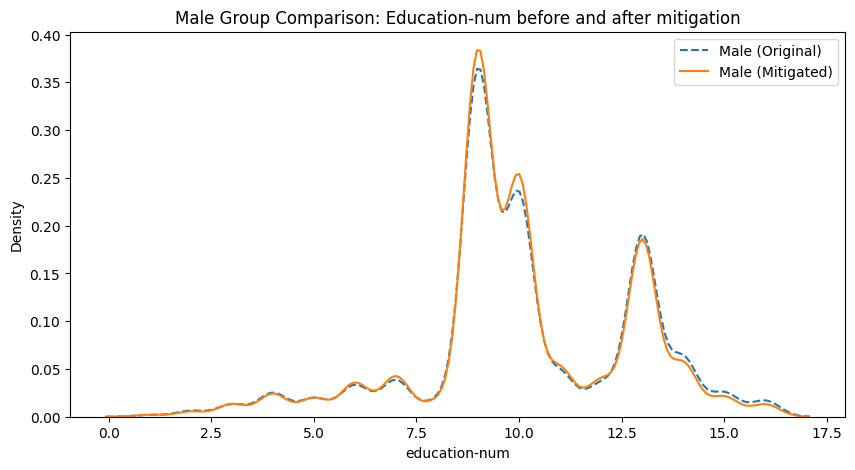

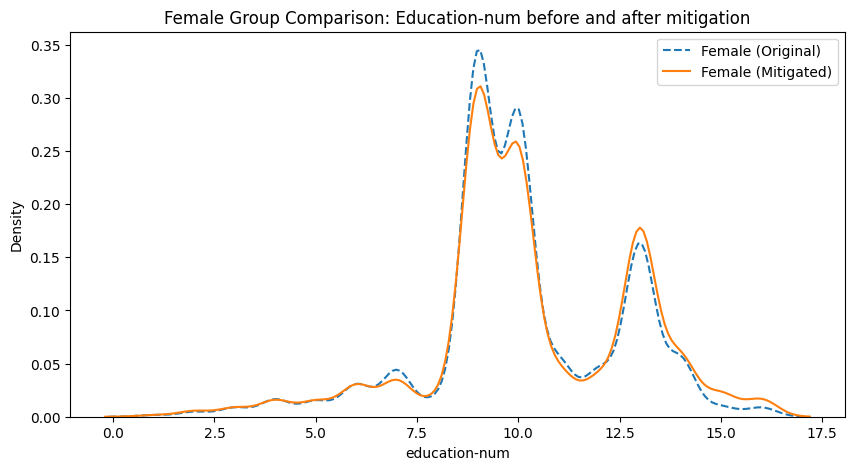

In [6]:
# ==== 4. visualize mitigation effect ====
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df.sex == 'Male'], x="education-num", label="Male (Original)", linestyle="--")
sns.kdeplot(data=df_mitigated[df_mitigated.sex == 'Male'], x="education-num", label="Male (Mitigated)")
plt.title("Male Group Comparison: Education-num before and after mitigation")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df.sex == 'Female'], x="education-num", label="Female (Original)", linestyle="--")
sns.kdeplot(data=df_mitigated[df_mitigated.sex == 'Female'], x="education-num", label="Female (Mitigated)")
plt.title("Female Group Comparison: Education-num before and after mitigation")
plt.legend()
plt.show()


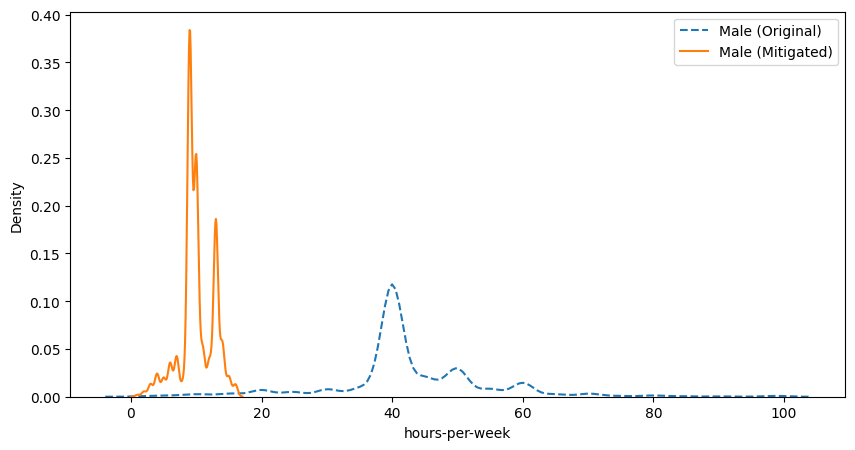

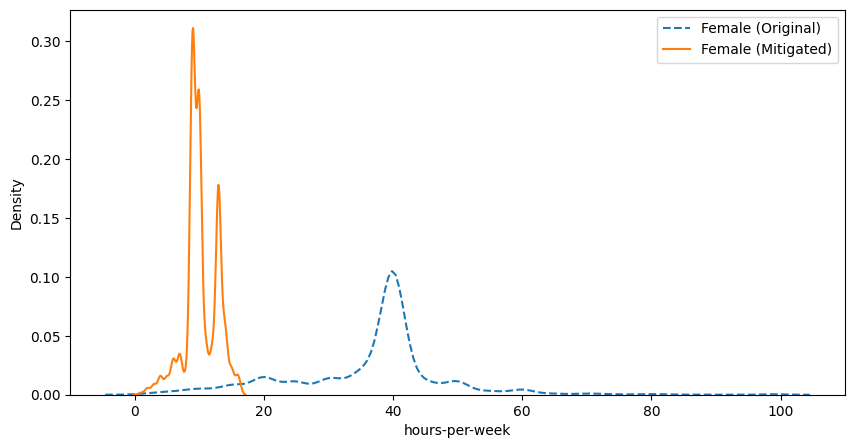

In [7]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df.sex == 'Male'], x="hours-per-week", label="Male (Original)", linestyle="--")
sns.kdeplot(data=df_mitigated[df_mitigated.sex == 'Male'], x="education-num", label="Male (Mitigated)")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(data=df[df.sex == 'Female'], x="hours-per-week", label="Female (Original)", linestyle="--")
sns.kdeplot(data=df_mitigated[df_mitigated.sex == 'Female'], x="education-num", label="Female (Mitigated)")
plt.legend()
plt.show()